# BIST Food Retail — Quarterly Financial Performance (2021–2025)

Exploratory analysis of four listed Turkish food-retailers — **BİM (BIMAS)**, **Migros (MGROS)**, **Şok (SOKM)** and **Bizim Toptan (BIZIM)** — over 20 quarters.

**Data:** borsapy (KAP filings), cross-checked against Yahoo Finance. **Currency:** TRY (nominal), with a CPI-deflated real-TRY view.

> **Methodology (important).** From FY2023, BIST firms report under inflation accounting (TMS 29). Differencing year-to-date statements into single quarters is unreliable, so this analysis uses **margins on cumulative YTD figures** and **annual figures**; discrete quarters are excluded from the core. Real-TRY levels are *indicative* (2021–2022 historical cost vs restated 2023+).

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# resolve project root whether run from notebooks/ or repo root
ROOT = Path.cwd()
if not (ROOT / 'data' / 'processed').exists():
    ROOT = ROOT.parent
PROC = ROOT / 'data' / 'processed'

q = pd.read_csv(PROC / 'quarterly_panel.csv')
a = pd.read_csv(PROC / 'annual_panel.csv')

COLORS = {'BIMAS': '#e4002b', 'MGROS': '#ff6600', 'SOKM': '#ffcc00', 'BIZIM': '#0066b3'}
NAME = dict(zip(q['company'], q['company_name']))
ORDER = ['BIMAS', 'MGROS', 'SOKM', 'BIZIM']
plt.rcParams['figure.dpi'] = 110
q.shape, a.shape

((80, 20), (20, 20))

## 1. Data overview

The dataset covers **four BIST-listed food retailers × 20 quarters (2021Q1–2025Q4)**, sourced from official KAP filings via `borsapy` and cross-checked against Yahoo Finance. All figures are consolidated and reported in nominal Turkish lira; a CPI-deflated real-TRY view is added in Section 5.

Two data-quality caveats shape everything downstream. First, from **FY2023 the companies report under inflation accounting (TMS 29)**, which opens a basis break between the historical-cost 2021–2022 period and the restated 2023+ period — so single-quarter (discrete) figures are unreliable, and the analysis is built on cumulative-YTD margins and annual figures instead. Second, the **detailed quarterly balance sheet is out of scope** (borsapy returns noisy, duplicated subtotal rows); only `total_assets` is cleanly recovered.

The summary below confirms the 4 × 20 coverage and that every core margin metric is fully populated, with no missing quarters.

In [2]:
print('Companies :', list(NAME.items()))
print('Quarters  :', q['quarter'].min(), '->', q['quarter'].max(),
      f"({q['quarter'].nunique()} quarters x {q['company'].nunique()} companies)")
print('\nNon-null coverage of key metrics:')
for m in ['gross_margin','operating_margin','net_margin','ebitda_margin','net_sales_ttm_real']:
    print(f'  {m:20s} {q[m].notna().sum()}/{len(q)}')
q.head()

Companies : [('BIMAS', 'BİM'), ('BIZIM', 'Bizim Toptan'), ('MGROS', 'Migros'), ('SOKM', 'Şok Marketler')]
Quarters  : 2021Q1 -> 2025Q4 (20 quarters x 4 companies)

Non-null coverage of key metrics:
  gross_margin         80/80
  operating_margin     80/80
  net_margin           80/80
  ebitda_margin        80/80
  net_sales_ttm_real   80/80


,quarter,company,company_name,net_sales_ytd,gross_profit_ytd,operating_profit_ytd,net_profit_ytd,ebitda_ytd,gross_margin,operating_margin,net_margin,ebitda_margin,net_sales_ytd_yoy,net_profit_ytd_yoy,ebitda_ytd_yoy,deflator,cpi_index,net_sales_ttm,net_sales_ttm_real,total_assets
0,2021Q1,BIMAS,BİM,1.550165e+10,2.853257e+09,9.483580e+08,6.845670e+08,1.355728e+09,18.406155,6.117789,4.416092,8.745704,23.052219,59.049606,35.514935,6.711140,1.328820,5.839939e+10,3.919265e+11,2.418090e+10
1,2021Q2,BIMAS,BİM,3.266489e+10,6.076210e+09,2.046501e+09,1.416243e+09,2.902431e+09,18.601653,6.265139,4.335673,8.885476,22.679903,25.573273,23.129459,6.417532,1.389615,6.153414e+10,3.948973e+11,2.508268e+10
2,2021Q3,BIMAS,BİM,5.012213e+10,9.357790e+09,3.141850e+09,2.308592e+09,4.445305e+09,18.669976,6.268389,4.605933,8.868947,24.724653,29.579995,23.340771,6.157269,1.448352,6.543127e+10,4.028779e+11,2.682794e+10
3,2021Q4,BIMAS,BİM,7.069851e+10,1.346003e+10,4.123282e+09,2.950710e+09,5.925940e+09,19.038634,5.832205,4.173652,8.381987,27.395339,13.192152,14.941164,5.115009,1.743476,7.069851e+10,3.616235e+11,3.041212e+10
4,2022Q1,BIMAS,BİM,2.731394e+10,5.067653e+09,1.802737e+09,1.344211e+09,2.359181e+09,18.553358,6.600062,4.921337,8.637278,76.200256,96.359304,74.015806,4.165258,2.141019,8.251080e+10,3.436788e+11,3.754356e+10


## 2. Margin analysis (core)
Margins on cumulative YTD figures are inflation-neutral and directly comparable across companies.

Reading the gross-margin panel (top-left of the grid above): the four retailers occupy distinct, persistent bands — **Migros highest** (mostly 24–25%, peaking at 27.6% in 2021Q1), **Şok** next (around 20%, high of 24.6% in 2022Q1), **BİM** in the high-teens (15–19%), and **Bizim Toptan lowest** throughout (8.7–16.7%).

All four compress sharply at **2022Q4**, the first annual report under inflation accounting: Migros falls from 25.0% (2022Q3) to 18.7%, BİM from 18.0% to 15.1%, Şok from 23.9% to 20.2%, and Bizim from 14.5% to 9.7%. Trough timing differs — Bizim bottoms first (8.7% in 2023Q1) and Şok latest (17.5% in 2024Q3). From 2024 onward all four recover; by 2025Q4 BİM (19.3%) and Bizim (16.7%) reach their window highs, while Migros (24.3%) and Şok (20.5%) climb back toward — but stay below — their 2021–2022 peaks of 27.6% and 24.6%.

> **📊 Analyst's read**
> The gross-margin bands are structural rather than transient — they reflect product mix and channel, which makes them the most reliable axis for cross-company comparison. The synchronized 2022Q4 step-down is an *accounting* event (inflation restatement of cost of goods), not a simultaneous loss of pricing power, so it should be read *through*; the 2024–2025 recovery back toward pre-2022 levels is the more telling signal of underlying margin resilience.

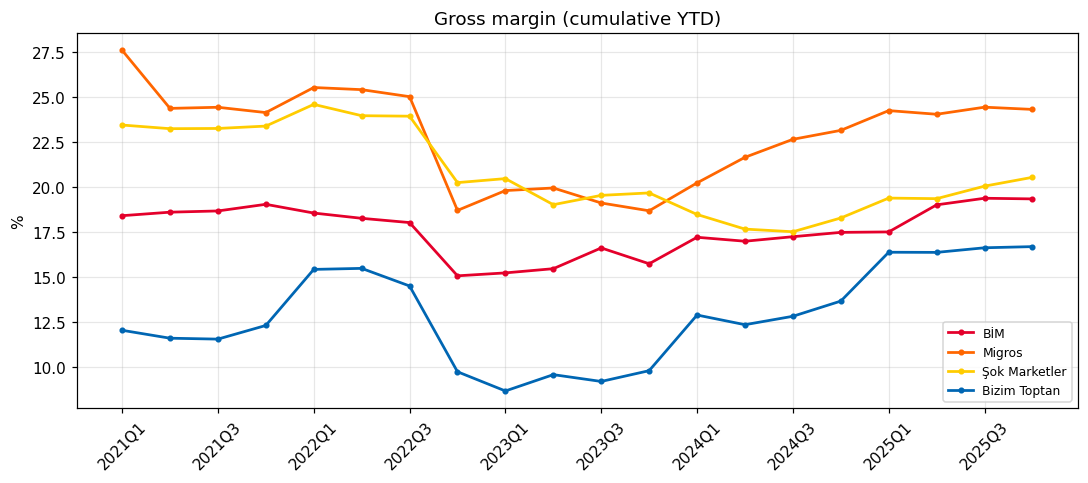

In [3]:
def margin_plot(metric, title):
    fig, ax = plt.subplots(figsize=(10, 4.5))
    for c in ORDER:
        d = q[q['company'] == c]
        ax.plot(d['quarter'], d[metric], marker='o', ms=3, lw=1.8,
                color=COLORS[c], label=NAME[c])
    ax.set_title(title); ax.set_ylabel('%'); ax.grid(alpha=.3)
    ax.set_xticks(d['quarter'][::2]); ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8); fig.tight_layout(); return ax

margin_plot('gross_margin', 'Gross margin (cumulative YTD)')
plt.show()

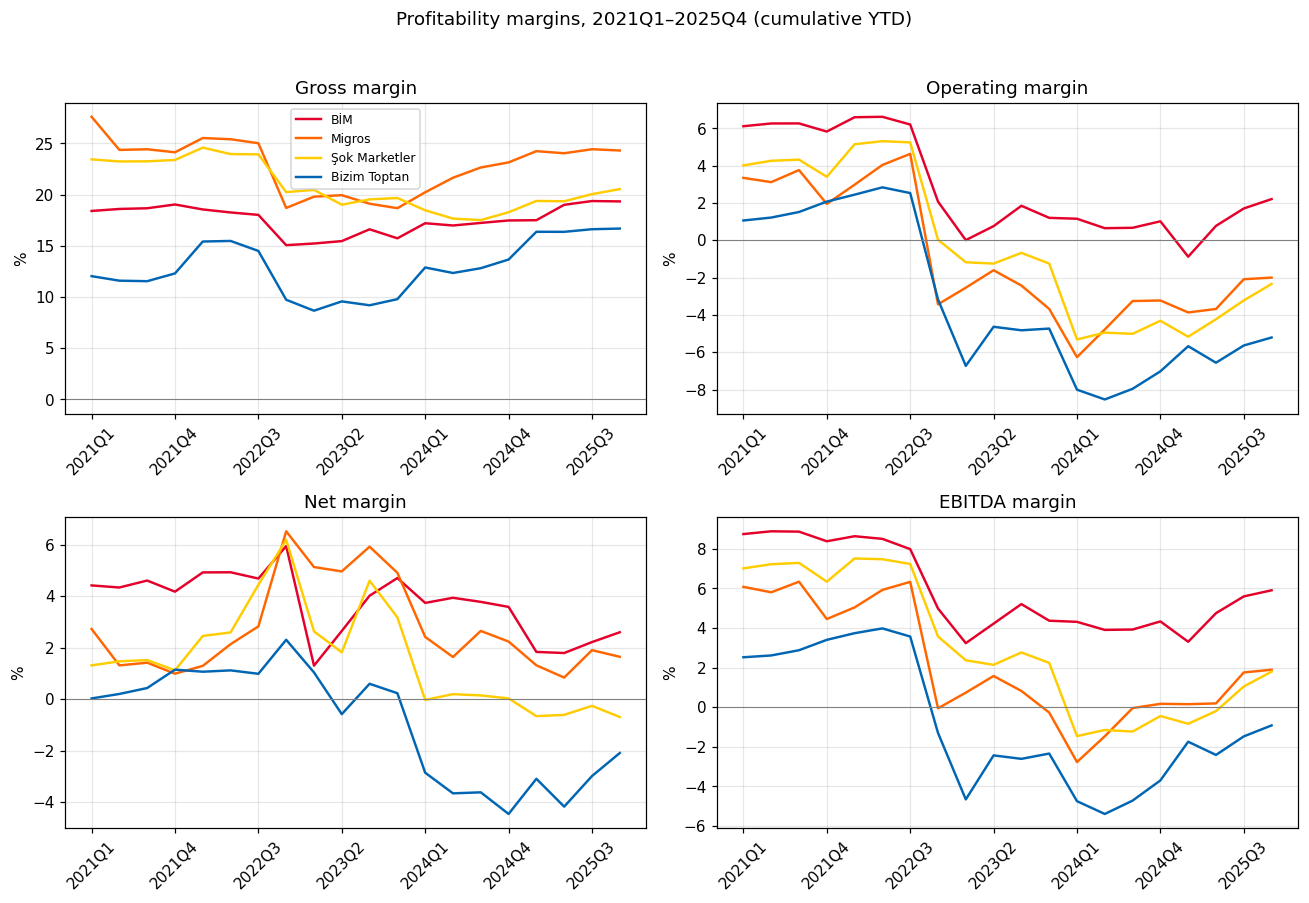

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
specs = [('gross_margin','Gross'),('operating_margin','Operating'),
         ('net_margin','Net'),('ebitda_margin','EBITDA')]
for ax,(m,t) in zip(axes.ravel(), specs):
    for c in ORDER:
        d = q[q['company']==c]
        ax.plot(d['quarter'], d[m], color=COLORS[c], lw=1.6, label=NAME[c])
    ax.axhline(0, color='grey', lw=.7)
    ax.set_title(f'{t} margin'); ax.set_ylabel('%'); ax.grid(alpha=.3)
    ax.set_xticks(d['quarter'][::3]); ax.tick_params(axis='x', rotation=45)
axes[0,0].legend(fontsize=8)
fig.suptitle('Profitability margins, 2021Q1–2025Q4 (cumulative YTD)', y=1.02)
fig.tight_layout(); plt.show()

## 3. Business-model comparison
Average margins over the window rank exactly by business model: full-line supermarket > hard discount > wholesale.

The ranking maps cleanly onto each business model:

- **Migros (full-line supermarket)** earns the widest gross margin (avg **22.9%**). A full assortment — fresh produce, deli, bakery, private label and non-food — carries higher mark-ups than a discount basket.
- **BİM and Şok (hard discount)** sit in the middle (**17.6%** and **20.8%**) by design: a narrow, high-turnover range of mostly private-label staples on thin mark-ups, built to drive volume.
- **Bizim Toptan (wholesale / cash-and-carry)** is thinnest (avg **12.9%**), the classic B2B trade-off of low margin for bulk throughput.

A useful nuance sits below the gross line. Despite only a *mid* gross margin, **BİM posts the highest average operating margin (2.9%, the only clearly positive one) and net margin (3.7%)**, versus Migros's −0.9% / 2.7%. The hard-discount model converts a leaner gross margin into the strongest bottom line through tight operating costs.

> **📊 Analyst's read**
> Gross margin alone would crown Migros, but profitability is won below the gross line — BİM's operating-cost discipline makes it the most profitable of the four. The takeaway for cross-company work is to compare like with like: gross margin measures pricing and mix, while operating and net margins capture the cost model, and a wider gross margin should not be read as automatically the stronger business.

,gross_margin,operating_margin,net_margin,ebitda_margin
BİM,17.6,2.9,3.7,5.9
Migros,22.9,-0.9,2.7,2.1
Şok Marketler,20.8,-0.4,1.6,3.0
Bizim Toptan,12.9,-3.2,-0.9,-0.8


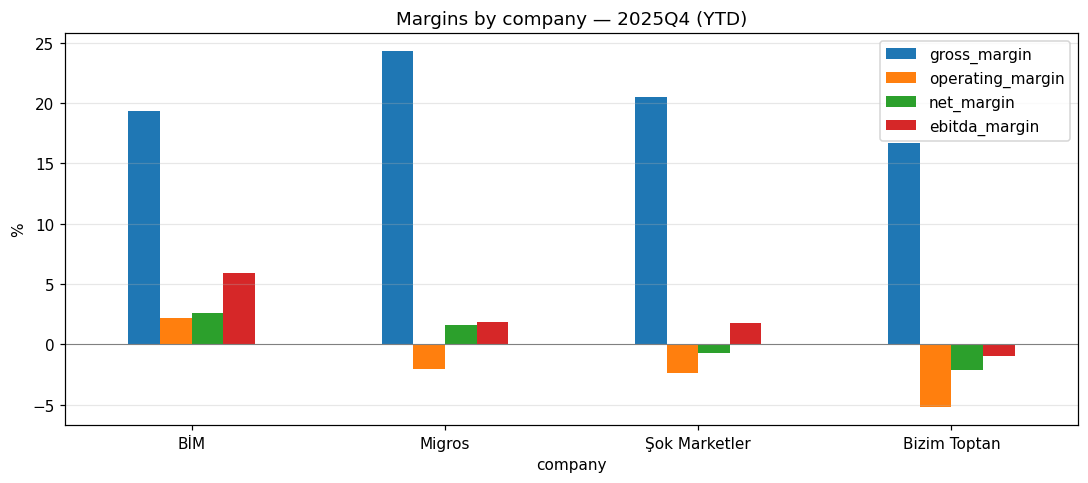

In [5]:
avg = (q.groupby('company')[['gross_margin','operating_margin','net_margin','ebitda_margin']]
         .mean().reindex(ORDER))
avg.index = [NAME[c] for c in avg.index]
display(avg.round(1))

latest = q[q['quarter'] == q['quarter'].max()].set_index('company').reindex(ORDER)
ax = latest[['gross_margin','operating_margin','net_margin','ebitda_margin']].plot(
    kind='bar', figsize=(10,4.5))
ax.set_xticklabels([NAME[c] for c in ORDER], rotation=0)
ax.set_title(f"Margins by company — {q['quarter'].max()} (YTD)"); ax.set_ylabel('%')
ax.axhline(0, color='grey', lw=.7); ax.grid(alpha=.3, axis='y'); plt.tight_layout(); plt.show()

## 4. The inflation-accounting (TMS 29) effect

Two fingerprints of inflation accounting are visible: (a) a margin compression in 2022–2023 as restatement kicks in, and (b) **operating margin diverging below net margin** — monetary-position gains on net trade payables are booked below the operating line, so net profit is lifted while operating profit is squeezed.

The inversion is precisely dated. Across the 7 quarters through 2022Q3, operating margin sits *above* net margin (the normal ordering, since net is struck after tax and interest). From **2022Q4 onward — all 13 quarters of the inflation-accounting era — net margin sits above operating margin for every one of the four companies**. Migros is the starkest case: a 2022Q4 operating margin of **−3.4%** against a net margin of **+6.5%**, a ~10-point wedge opened entirely by the monetary-position gain.

> **📊 Analyst's read — a Turkey-specific caveat**
> Under TMS 29, a retailer's large net trade-payable position produces a purchasing-power *gain* booked below the operating line, so reported operating profit understates — and net profit overstates — true operating performance. Taken at face value, Migros and Şok appear loss-making at the operating level while staying net-profitable; that is an accounting artefact, not an operational collapse. When comparing operating performance across Turkish companies, or against pre-2023 history, an analyst should strip out the monetary gain/loss and lean on **gross margin and operating proxies** rather than the reported operating line.

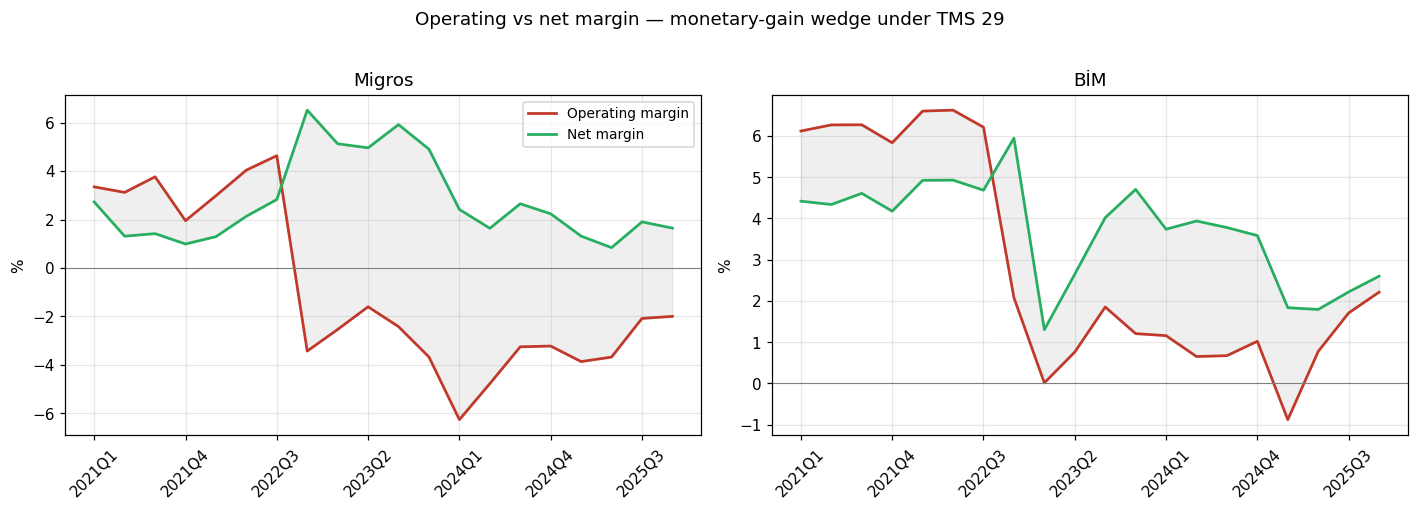

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
for ax, c in zip(axes, ['MGROS','BIMAS']):
    d = q[q['company']==c]
    ax.plot(d['quarter'], d['operating_margin'], color='#c0392b', lw=1.8, label='Operating margin')
    ax.plot(d['quarter'], d['net_margin'], color='#27ae60', lw=1.8, label='Net margin')
    ax.fill_between(d['quarter'], d['operating_margin'], d['net_margin'], alpha=.12, color='grey')
    ax.axhline(0, color='grey', lw=.7); ax.set_title(NAME[c]); ax.set_ylabel('%')
    ax.set_xticks(d['quarter'][::3]); ax.tick_params(axis='x', rotation=45); ax.grid(alpha=.3)
axes[0].legend(fontsize=9)
fig.suptitle('Operating vs net margin — monetary-gain wedge under TMS 29', y=1.02)
fig.tight_layout(); plt.show()

## 5. Real growth — annual net sales in real TRY
*Indicative:* deflated to 2025Q4 prices via TÜFE CPI. Read the 2021→2022 step with care (historical cost → restated basis change).

The gap between nominal and real growth is the headline. In 2025, **all four post positive nominal sales growth yet shrink in real terms**: BİM +16.7% nominal but −10.9% real, Migros +18.1% / −9.8%, Şok +15.9% / −11.4%. With CPI near 31% over the year, double-digit nominal growth still loses ground to inflation.

Measured from 2022 (the first fully restated year, sidestepping the historical-cost basis break) to 2025, **Migros is the only company to grow real revenue (+4%)**; BİM (−9%) and Şok (−12%) contract modestly, while **Bizim Toptan falls about −56% in real terms** — and in 2025 it is the only one shrinking even nominally (−13.3%), pointing to genuine pressure on the cash-and-carry channel rather than an inflation-optics effect.

> **📊 Analyst's read**
> Nominal TRY top-line growth is largely an inflation mirage here — the real series tells the opposite story for three of the four. The 2021→2022 jump (roughly +135–171% "real") is **not** growth; it is the historical-cost-to-restated basis change and must not be read as performance. Treating the real figures as *indicative* rather than precise, the durable signal is divergence: Migros defends real scale, the discounters tread water, and Bizim Toptan is in real-terms retreat.

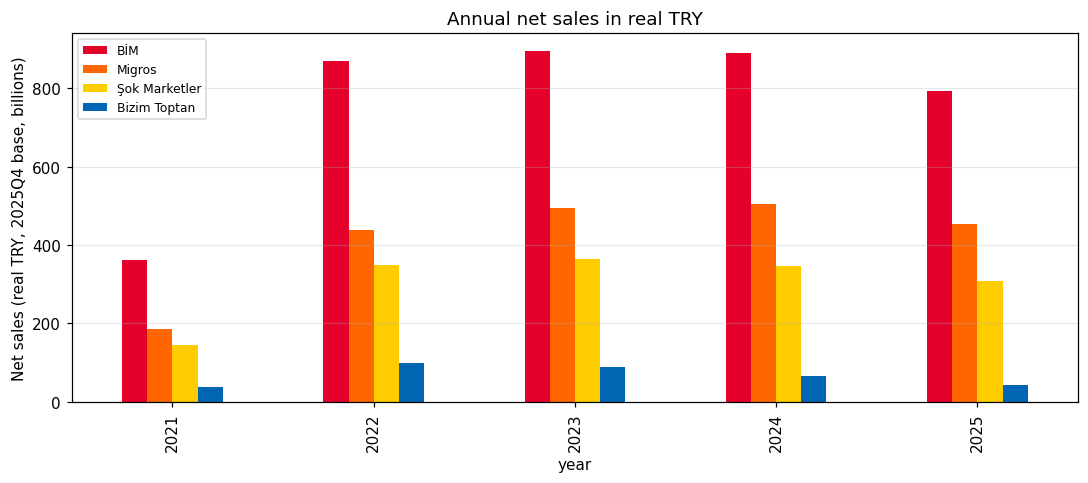

company,BIMAS,MGROS,SOKM,BIZIM
year,,,,
2021,NaN,NaN,NaN,NaN
2022,140.5,135.8,140.8,171.1
2023,3.1,13.2,4.3,-11.6
2024,-0.7,1.6,-5.1,-25.5
2025,-10.9,-9.8,-11.4,-33.8


In [7]:
piv = a.pivot(index='year', columns='company', values='net_sales_fy_real')[ORDER] / 1e9
ax = piv.plot(kind='bar', figsize=(10,4.5), color=[COLORS[c] for c in ORDER])
ax.set_ylabel('Net sales (real TRY, 2025Q4 base, billions)')
ax.set_title('Annual net sales in real TRY'); ax.legend([NAME[c] for c in ORDER], fontsize=8)
ax.grid(alpha=.3, axis='y'); plt.tight_layout(); plt.show()

yoy = a.pivot(index='year', columns='company', values='net_sales_fy_yoy_real')[ORDER]
display(yoy.round(1))

## 6. Key takeaways

- **Margins rank by business model.** Migros (full-line) earns the richest gross margin (~24%), the hard discounters BİM/Şok sit ~19–20%, and Bizim (wholesale) is thinnest (~17%).
- **Inflation accounting left a clear mark:** a 2022–2023 margin trough across all four, then recovery into 2024–2025.
- **Operating vs net margin diverge** under TMS 29 (monetary gains below the operating line) — a Turkey-specific reading caveat.
- **In real terms**, top-line growth is far more muted than nominal TRY suggests; Bizim Toptan in particular erodes in real revenue over the window.

*Next steps: per-store / inventory metrics (needs cleaner balance-sheet parsing), and a USD-translated view alongside real-TRY.*